# TD-TP N° 2 Machine Learning & Text Mining
## Techniques de régression
**Année Universitaire: 2022-2023**

## Exercice 1: Régression linéaire simple

**Travail à faire:**
1. Analyser le programme ci-dessous en identifiant (datasets, input, output, technique utilisée...)
2. Identifier les étapes nécessaires à une application de Machine Learning (training data, testing data, testing...)
3. Quelle est le rôle de iloc ?
4. Exécuter et tester le programme
5. Afficher les valeurs de Slope, intercept, coefficient de corrélation ?
6. Prédire une estimation pour x=22.5

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [22]:
df = pd.read_csv('univariate_linear_regression_dataset.csv')

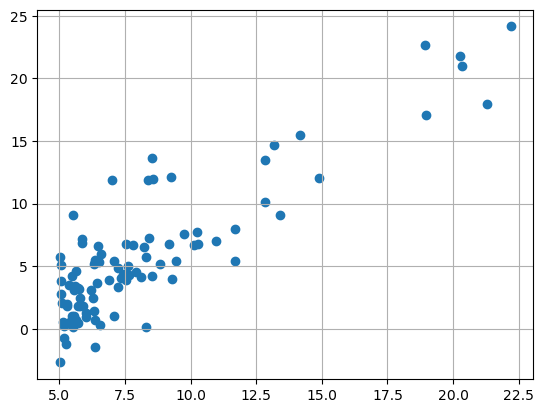

In [23]:
X = df.iloc[:,0]
Y = df.iloc[:,1]

axes = plt.axes()
axes.grid()
plt.scatter(X,Y)
plt.show()

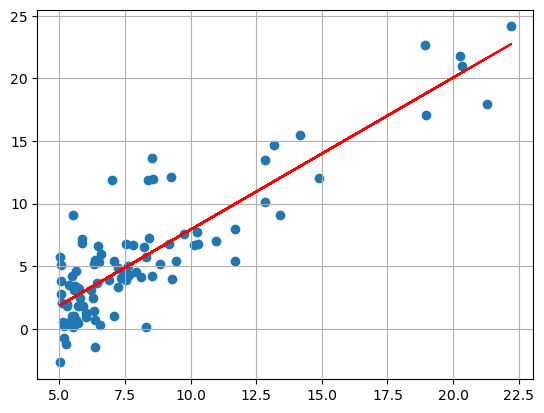

In [24]:
SL=stats.linregress(X, Y)
slope=SL.slope; intercept=SL.intercept; coef_correlation=SL.rvalue

def predict(x):
    return slope * x + intercept

axes = plt.axes()
axes.grid()
plt.scatter(X,Y)
fitLine = predict(X)
plt.plot(X, fitLine, c='r')
plt.show()

### Réponses:

**Question 1:** Analyse du programme
- **Réponse:**
    - **Dataset:** `univariate_linear_regression_dataset.csv` - un fichier CSV contenant des données pour la régression linéaire à une variable
    - **Input:** Variable X (première colonne du dataset) - variable prédictive/indépendante
    - **Output:** Variable Y (deuxième colonne du dataset) - variable cible/dépendante
    - **Technique utilisée:** Régression linéaire simple avec `stats.linregress()` de scipy


**Question 2:** Étapes de Machine Learning
- Réponse:

**Question 3:** Rôle de iloc
- Réponse:

**Question 5:** Afficher les valeurs de Slope, intercept, coefficient de corrélation

In [12]:
# Votre code ici pour afficher slope, intercept, coef_correlation
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Coefficient of Correlation: {coef_correlation}")

Slope: 1.1930336441895941
Intercept: -3.8957808783118555
Coefficient of Correlation: 0.837873232526341


**Question 6:** Prédire une estimation pour x=22.5

In [14]:
# Votre code ici pour prédire pour x=22.5

prediction = predict(22.5)

print(f"Prediction for x=22.5: {prediction}")

Prediction for x=22.5: 22.94747611595401


## Exercice 2: Régression avec Gradient Descent

**Travail à faire:**
1. Analyser le programme ci-dessous en identifiant (datasets, input, output, technique utilisée...)
2. Exécuter et tester le programme
3. Quel est le rôle de n_iterations et learning_rate ? modifier la valeur et identifier l'impact sur le modèle ?

In [20]:
df = pd.read_csv('univariate_linear_regression_dataset.csv')

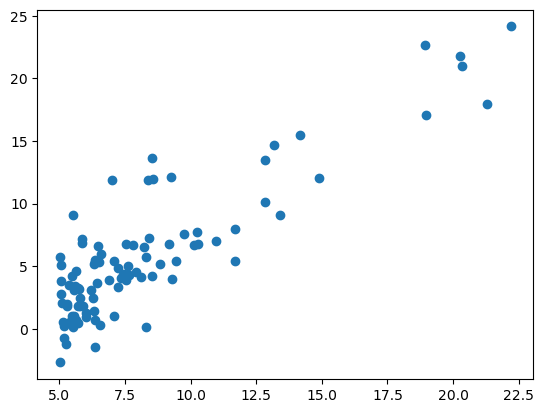

In [28]:
X = df.iloc[:,0] 
n_samples = len(X)
x=np.array(X).reshape((n_samples, 1))

Y = df.iloc[:,1]
y=np.array(Y).reshape((n_samples, 1))

plt.scatter(x, y) 
plt.show()

In [29]:
# ajout de la colonne de biais x-X
X = np.hstack((x, np.ones(x.shape)))
# Initiation d'un vecteur parametre theta
theta = np.random.rand(2, 1)
print(theta)

[[0.8266758 ]
 [0.29588578]]


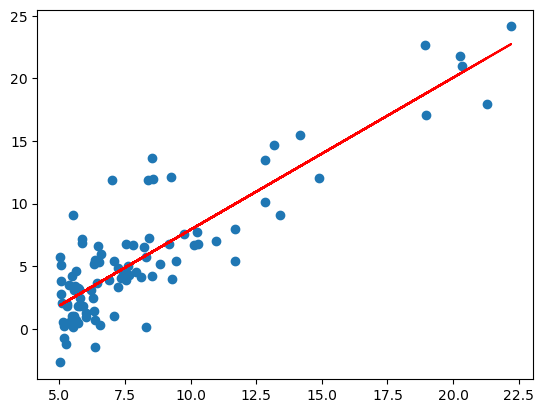

In [32]:
def f(X, theta):
    return X.dot(theta)

def erreur_somme_des_distances(X, y, theta):
    m = len(y)
    return (1/(2*m))*np.sum((f(X, theta)-y)**2)

def gradient(X, y, theta):
    m = len(y)
    return (1/m) * X.T.dot(f(X, theta) - y)

def gradient_descent(X, y, theta, learning_rate, n_iterations):
    # création d'un tableau de stockage pour enregistrer l'évolution des erreurs
    historique_des_erreurs = np.zeros(n_iterations)
    for i in range(0, n_iterations):
        theta = theta - learning_rate * gradient(X, y, theta) # mise à jour du theta
        historique_des_erreurs[i] = erreur_somme_des_distances(X, y, theta)
    return theta, historique_des_erreurs

# Example de test :
n_iterations = 10000
learning_rate = 0.01
# modifier pour voir l'effet
theta_final, historique_des_erreurs=gradient_descent(X, y, theta, learning_rate, n_iterations)

# creation d'un vecteur prédictions qui contient les prédictions de notre modèle final
predictions = f(X, theta_final)

# Affiche les résultats de prédictions (en rouge) par rapport à notre Dataset (en bleu)
plt.scatter(x, y)
plt.plot(x, predictions, c='r')
plt.show()

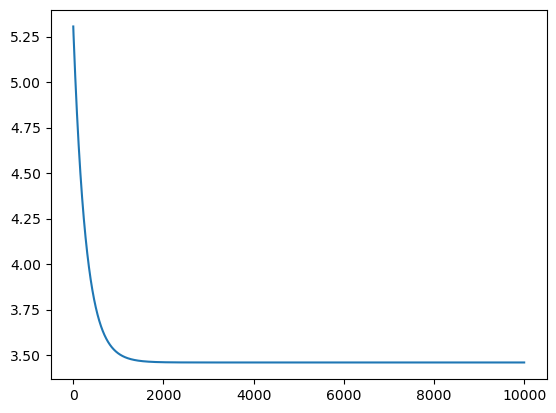

np.array([22.5,1]), theta_final)


In [31]:
plt.figure()
plt.plot(range(n_iterations), historique_des_erreurs)
plt.show()

print(f'np.array([22.5,1]), theta_final)')

### Réponses:

**Question 1:** Analyse du programme
- **Réponse:**
- **Dataset:** `univariate_linear_regression_dataset.csv` - un fichier CSV contenant des données pour la régression linéaire à une variable
- **Input:** Variable X (première colonne du dataset) - variable prédictive/indépendante  
- **Output:** Variable Y (deuxième colonne du dataset) - variable cible/dépendante
- **Technique utilisée:** Régression linéaire avec descente de gradient (Gradient Descent) - une méthode d'optimisation itérative pour trouver les paramètres optimaux (theta) du modèle linéaire

**Question 3:** Rôle de n_iterations et learning_rate
- **Réponse:**
- **n_iterations:** Nombre d'itérations de l'algorithme de descente de gradient. Plus ce nombre est élevé, plus l'algorithme a de chances de converger vers les paramètres optimaux.
- **learning_rate:** Taux d'apprentissage qui contrôle la taille des pas lors de la mise à jour des paramètres theta. 
    - Si trop petit: la convergence sera très lente et nécessitera beaucoup d'itérations
    - Si trop grand: l'algorithme peut diverger ou osciller sans jamais converger vers l'optimum
    - Une valeur appropriée permet une convergence rapide et stable vers les paramètres optimaux

## Exercice 3: Régression polynomiale

**Travail à faire:**
1. Analyser le programme ci-dessous en identifiant (dataset, input, output, technique utilisée...)
2. Quel est le rôle des fonctions afficher_pol et evaluer_pol ?
3. Exécuter et tester le programme
4. Est-ce que le polynôme modélise correctement la relation entre la variable prédictive et la variable cible ? sinon chercher une polynôme adéquate ?

In [39]:
def afficher_pol(LPol):
    L=LPol[:]; L.reverse()
    L=[round(e,2) for e in L]

    for i in range(len(L)):
        if i != len(L)-1:
            print('('+str(L[i])+'*X^'+str(i)+')',end=' + ')
        else:
            print('('+str(L[i])+'*X^'+str(i)+')')

def Evaluer_pol(LPol,x):
    s=0
    L=LPol[:]
    L.reverse()
    for i in range(len(LPol)):
        s+=L[i]*(x**i)
    return(s)

data=pandas.read_csv('dataset_polynomial3.csv').values

print(data)

x=data[1:1001,0]
y=data[1:1001,1]

[[ 2.69151718 -0.48494203]
 [ 1.33394826  0.39681172]
 [ 0.71045428 -0.8569272 ]
 ...
 [ 0.13748415 -6.83358907]
 [ 0.75902601 -0.70444958]
 [ 3.99489162  6.33265488]]


### Réponses:

**Question 1:** Analyse du programme
- **Réponse:**
    - **Dataset:** `dataset_polynomial3.csv` - un fichier CSV contenant des données pour la régression polynomiale
    - **Input:** Variable x (première colonne du dataset) - variable prédictive/indépendante
    - **Output:** Variable y (deuxième colonne du dataset) - variable cible/dépendante
    - **Technique utilisée:** Régression polynomiale avec `np.polyfit()` qui ajuste un polynôme de degré spécifié aux données

**Question 2:** Rôle des fonctions afficher_pol et evaluer_pol
- **Réponse:**
    - **afficher_pol(LPol):** Affiche le polynôme sous forme mathématique lisible en inversant l'ordre des coefficients et en les formatant comme une somme de termes (coefficient * X^puissance)
    - **Evaluer_pol(LPol, x):** Évalue le polynôme pour une valeur x donnée en calculant la somme des termes (coefficient * x^puissance) pour tous les coefficients du polynôme

**Question 4:** Le polynôme modélise-t-il correctement la relation ?
- **Réponse:**
    - Non, un polynôme de degré 2 ne modélise pas correctement la relation entre les variables. En observant les données, on constate qu'il s'agit d'un dataset polynomial de degré 3 (d'après le nom du fichier). Il faudrait augmenter le degré du polynôme à 3 pour obtenir un meilleur ajustement. On peut tester différents degrés (3, 4, 5...) pour identifier le degré optimal qui modélise correctement les données sans sur-apprentissage.

Degré du polynôme: 1
(-3.34*X^0) + (1.68*X^1)


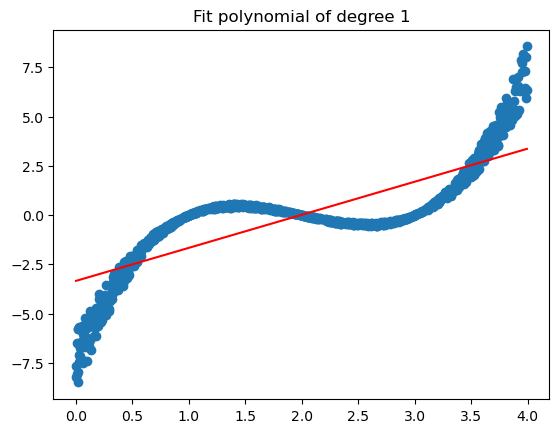

Degré du polynôme: 2
(-3.45*X^0) + (1.84*X^1) + (-0.04*X^2)


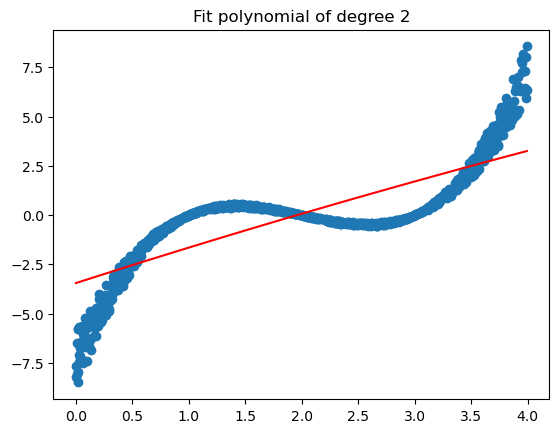

Degré du polynôme: 3
(-7.38*X^0) + (13.53*X^1) + (-7.38*X^2) + (1.23*X^3)


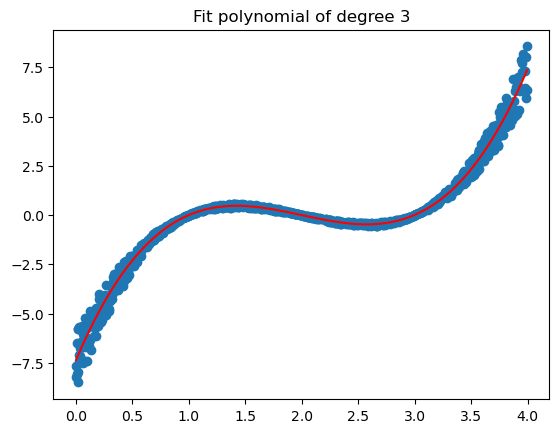

Degré du polynôme: 4
(-7.4*X^0) + (13.6*X^1) + (-7.47*X^2) + (1.26*X^3) + (-0.0*X^4)


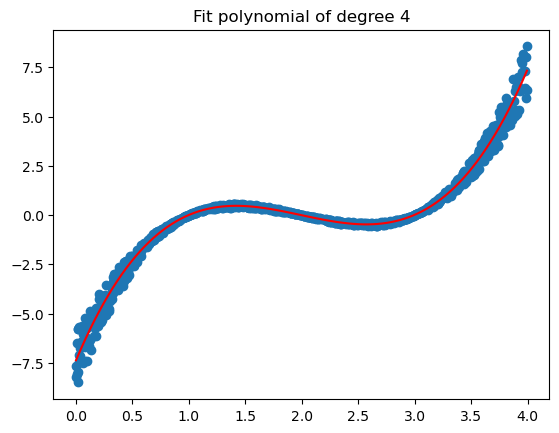

In [ ]:
for degre_polynome in range(1, 5):
    p = np.poly1d(np.polyfit(x, y, degre_polynome))
    LPol = list(p)

    print(f"Degré du polynôme: {degre_polynome}")
    
    afficher_pol(LPol)

    les_x = np.linspace(min(x), max(x), 100)
    plt.scatter(x, y)
    plt.plot(les_x, p(les_x), c='r')
    plt.title(f"Fit polynomial of degree {degre_polynome}")
    plt.show()